<a href="https://colab.research.google.com/github/yasirsiddiq01/6G-noma-demapper/blob/main/6G_noma_demapper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install required packages
!pip install tensorflow numpy matplotlib scipy scikit-learn

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from scipy import special
import time

print("✅ Libraries imported")
print("GPU Available:", tf.config.list_physical_devices('GPU'))

✅ Libraries imported
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
class NOMASystem:
    """
    Simulates an uplink NOMA system with two users
    """
    def __init__(self, num_users=2, modulation='QPSK', snr_db=20):
        self.num_users = num_users
        self.snr_db = snr_db
        self.set_modulation(modulation)

    def set_modulation(self, modulation):
        """Set modulation scheme and constellation"""
        if modulation == 'QPSK':
            self.constellation = np.array([1+1j, 1-1j, -1+1j, -1-1j]) / np.sqrt(2)
            self.bits_per_symbol = 2
        elif modulation == '16QAM':
            # 16QAM constellation
            symbols = []
            for i in [-3, -1, 1, 3]:
                for q in [-3, -1, 1, 3]:
                    symbols.append((i + 1j*q) / np.sqrt(10))
            self.constellation = np.array(symbols)
            self.bits_per_symbol = 4
        self.M = len(self.constellation)  # Modulation order

    def generate_bits(self, num_symbols):
        """Generate random bits for all users"""
        bits_per_user = num_symbols * self.bits_per_symbol
        bits = np.random.randint(0, 2, (self.num_users, bits_per_user))
        return bits

    def modulate(self, bits):
        """Map bits to constellation symbols"""
        num_symbols = bits.shape[1] // self.bits_per_symbol
        symbols = np.zeros((self.num_users, num_symbols), dtype=complex)

        for user in range(self.num_users):
            for i in range(num_symbols):
                # Get bits for this symbol
                symbol_bits = bits[user, i*self.bits_per_symbol:(i+1)*self.bits_per_symbol]
                # Convert bits to index
                idx = 0
                for b in symbol_bits:
                    idx = (idx << 1) | b
                symbols[user, i] = self.constellation[idx]

        return symbols

    def apply_noma_power(self, symbols, power_ratio=0.8):
        """
        Apply NOMA power domain multiplexing
        User 1 gets more power (near user), User 2 gets less power (far user)
        """
        # Power allocation coefficients (α² + β² = 1)
        alpha = np.sqrt(power_ratio)  # Near user (more power)
        beta = np.sqrt(1 - power_ratio)  # Far user (less power)

        # Scale symbols
        scaled_symbols = symbols.copy()
        scaled_symbols[0] *= alpha  # Near user
        scaled_symbols[1] *= beta   # Far user

        return scaled_symbols, alpha, beta

    def add_channel_effects(self, symbols):
        """
        Add realistic channel effects:
        - Rayleigh fading (different for each user)
        - AWGN noise
        """
        num_symbols = symbols.shape[1]

        # Channel coefficients (Rayleigh fading)
        h = (np.random.randn(self.num_users, num_symbols) +
             1j * np.random.randn(self.num_users, num_symbols)) / np.sqrt(2)

        # Apply channel
        received = np.sum(h * symbols, axis=0)

        # Add noise
        signal_power = np.mean(np.abs(received)**2)
        noise_power = signal_power / (10**(self.snr_db/10))
        noise = (np.random.randn(num_symbols) +
                 1j * np.random.randn(num_symbols)) * np.sqrt(noise_power/2)

        received += noise

        return received, h

    def generate_batch(self, batch_size=1000, symbols_per_frame=100):
        """
        Generate a batch of training data
        Returns: (received_signal, true_bits_for_both_users)
        """
        X = []  # Received signals (features)
        y1 = [] # User 1 bits (target)
        y2 = [] # User 2 bits (target)

        for _ in range(batch_size):
            # Generate bits for both users
            bits = self.generate_bits(symbols_per_frame)

            # Modulate
            symbols = self.modulate(bits)

            # Apply NOMA power allocation
            symbols, alpha, beta = self.apply_noma_power(symbols)

            # Add channel effects
            received, h = self.add_channel_effects(symbols)

            # Features: [received_signal_real, received_signal_imag,
            #           channel_magnitude_user1, channel_magnitude_user2]
            features = np.stack([
                np.real(received),
                np.imag(received),
                np.abs(h[0]),  # Channel magnitude for user 1
                np.abs(h[1])   # Channel magnitude for user 2
            ], axis=1)

            X.append(features)
            y1.append(bits[0])
            y2.append(bits[1])

        return np.array(X), np.array(y1), np.array(y2)

In [4]:
class TraditionalDemappers:
    """
    Traditional demapping techniques for comparison
    """

    @staticmethod
    def sic_demapper(received, h, alpha, beta, constellation):
        """
        Successive Interference Cancellation (SIC)
        - Decode stronger user first, subtract its interference
        - Then decode weaker user
        """
        M = len(constellation)
        bits_per_symbol = int(np.log2(M))

        # Step 1: Decode User 1 (stronger, with alpha)
        # Equalize channel for user 1
        y1_eq = received / h[0]

        # Find closest constellation points for user 1
        detected_bits1 = []
        for sym in y1_eq:
            # Compute distances to all constellation points
            distances = np.abs(sym - constellation)
            closest_idx = np.argmin(distances)

            # Convert index to bits
            bits = [(closest_idx >> b) & 1 for b in range(bits_per_symbol-1, -1, -1)]
            detected_bits1.extend(bits)

        # Step 2: Subtract user 1's interference and decode user 2
        # Reconstruct user 1's signal
        symbols1 = constellation[[int(''.join(map(str, detected_bits1[i:i+bits_per_symbol])), 2)
                                  for i in range(0, len(detected_bits1), bits_per_symbol)]]

        # Subtract from received signal
        remaining = received - h[0] * alpha * symbols1

        # Equalize for user 2
        y2_eq = remaining / h[1]

        # Decode user 2
        detected_bits2 = []
        for sym in y2_eq:
            distances = np.abs(sym / beta - constellation)  # Remove power scaling
            closest_idx = np.argmin(distances)
            bits = [(closest_idx >> b) & 1 for b in range(bits_per_symbol-1, -1, -1)]
            detected_bits2.extend(bits)

        return np.array(detected_bits1), np.array(detected_bits2)

    @staticmethod
    def joint_demapper(received, h, alpha, beta, constellation):
        """
        Joint Maximum Likelihood demapper
        Searches over all possible symbol pairs
        """
        M = len(constellation)
        bits_per_symbol = int(np.log2(M))

        detected_bits1 = []
        detected_bits2 = []

        for t in range(len(received)):
            # Search over all possible symbol pairs
            min_dist = float('inf')
            best_pair = (0, 0)

            for i, s1 in enumerate(constellation):
                for j, s2 in enumerate(constellation):
                    # Construct received signal for this pair
                    reconstructed = h[0,t] * alpha * s1 + h[1,t] * beta * s2
                    dist = np.abs(received[t] - reconstructed)**2

                    if dist < min_dist:
                        min_dist = dist
                        best_pair = (i, j)

            # Convert indices to bits
            i, j = best_pair
            bits1 = [(i >> b) & 1 for b in range(bits_per_symbol-1, -1, -1)]
            bits2 = [(j >> b) & 1 for b in range(bits_per_symbol-1, -1, -1)]

            detected_bits1.extend(bits1)
            detected_bits2.extend(bits2)

        return np.array(detected_bits1), np.array(detected_bits2)

In [7]:
def build_sicnet_demapper(input_dim=4, output_dim=4, hidden_units=[128, 256, 128]):
    """
    Neural network demapper that learns SIC-like behavior
    Architecture inspired by SICNet from CTTC research [citation:9]
    """
    inputs = layers.Input(shape=(input_dim,))

    # Shared layers
    x = layers.Dense(hidden_units[0], activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(hidden_units[1], activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(hidden_units[2], activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Two output heads (one for each user)
    user1_output = layers.Dense(output_dim, activation='sigmoid', name='user1')(x)
    user2_output = layers.Dense(output_dim, activation='sigmoid', name='user2')(x)

    model = models.Model(inputs=inputs, outputs=[user1_output, user2_output])
    return model

# Build model
sicnet = build_sicnet_demapper(input_dim=4, output_dim=2)  # 2 bits per symbol for QPSK
sicnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
sicnet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │        640 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     33,024 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     32,896 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user1 (Dense)       │ (None, 2)         │        258 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user2 (Dense)       │ (None, 2)         │        258 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,124 (270.02 KB)

 Trainable params: 68,100 (266.02 KB)

 Non-trainable params: 1,024 (4.00 KB)

Generating training data...
Original shapes:
X_train: (5000, 50, 4)
y1_train: (5000, 100)
y2_train: (5000, 100)

Reshaped for training:
X_train_reshaped: (250000, 4)
y1_train_reshaped: (250000, 2)
y2_train_reshaped: (250000, 2)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 128)       │        640 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │     33,024 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_10[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 128)       │     32,896 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_11[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user1 (Dense)       │ (None, 2)         │        258 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user2 (Dense)       │ (None, 2)         │        258 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,124 (270.02 KB)

 Trainable params: 68,100 (266.02 KB)

 Non-trainable params: 1,024 (4.00 KB)


Starting training...
Epoch 1/20
7813/7813 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - loss: 1.4205 - user1_accuracy: 0.5062 - user1_loss: 0.7099 - user2_accuracy: 0.4995 - user2_loss: 0.7106 - val_loss: 1.3919 - val_user1_accuracy: 0.4582 - val_user1_loss: 0.6944 - val_user2_accuracy: 0.5930 - val_user2_loss: 0.6974
Epoch 2/20
7813/7813 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - loss: 1.3908 - user1_accuracy: 0.5046 - user1_loss: 0.6954 - user2_accuracy: 0.4826 - user2_loss: 0.6953 - val_loss: 1.3913 - val_user1_accuracy: 0.4027 - val_user1_loss: 0.6952 - val_user2_accuracy: 0.5230 - val_user2_loss: 0.6962
Epoch 3/20
7813/7813 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - loss: 1.3889 - user1_accuracy: 0.5068 - user1_loss: 0.6945 - user2_accuracy: 0.4895 - user2_loss: 0.6945 - val_loss: 1.3884 - val_user1_accuracy: 0.6582 - val_user1_loss: 0.6941 - val_user2_accuracy: 0.5366 - val_user2_loss: 0.6944
Epoch 4/20
7813/7813 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - loss: 1.3875 - user1_accuracy: 0.5047 - user1_loss: 0.

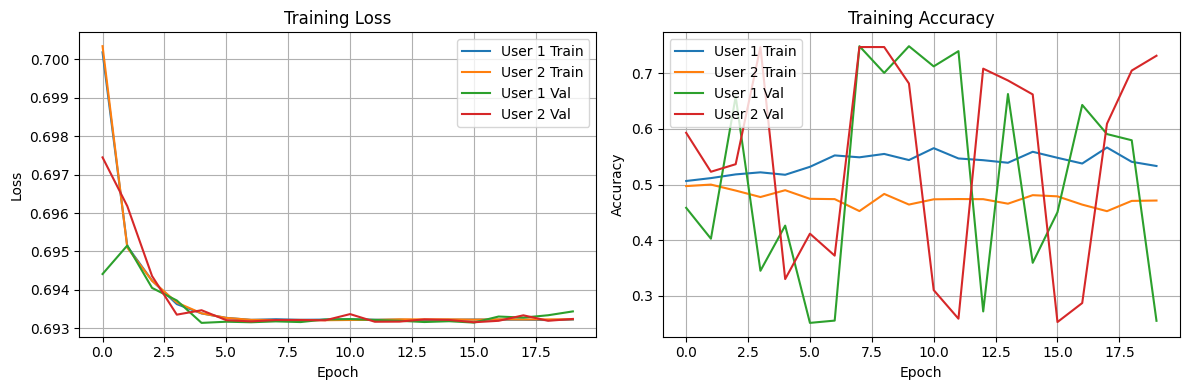

In [10]:
# Initialize NOMA system
noma = NOMASystem(num_users=2, modulation='QPSK', snr_db=15)

# Generate training data
print("Generating training data...")
X_train, y1_train, y2_train = noma.generate_batch(batch_size=5000, symbols_per_frame=50)
X_val, y1_val, y2_val = noma.generate_batch(batch_size=1000, symbols_per_frame=50)

print(f"Original shapes:")
print(f"X_train: {X_train.shape}")  # (5000, 50, 4)
print(f"y1_train: {y1_train.shape}")  # (5000, 100) - 50 symbols * 2 bits = 100 bits
print(f"y2_train: {y2_train.shape}")  # (5000, 100)

# Reshape the data to process each symbol independently
X_train_reshaped = X_train.reshape(-1, 4)  # (5000*50, 4) = (250000, 4)
X_val_reshaped = X_val.reshape(-1, 4)      # (1000*50, 4) = (50000, 4)

# For QPSK, each symbol has 2 bits
bits_per_symbol = 2
y1_train_reshaped = y1_train.reshape(-1, bits_per_symbol)  # (250000, 2)
y2_train_reshaped = y2_train.reshape(-1, bits_per_symbol)  # (250000, 2)
y1_val_reshaped = y1_val.reshape(-1, bits_per_symbol)      # (50000, 2)
y2_val_reshaped = y2_val.reshape(-1, bits_per_symbol)      # (50000, 2)

print(f"\nReshaped for training:")
print(f"X_train_reshaped: {X_train_reshaped.shape}")
print(f"y1_train_reshaped: {y1_train_reshaped.shape}")
print(f"y2_train_reshaped: {y2_train_reshaped.shape}")

# Build model
def build_sicnet_demapper(input_dim=4, output_dim=2, hidden_units=[128, 256, 128]):
    """
    Neural network demapper that learns SIC-like behavior
    """
    inputs = layers.Input(shape=(input_dim,))

    # Shared layers
    x = layers.Dense(hidden_units[0], activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(hidden_units[1], activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(hidden_units[2], activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Two output heads (one for each user)
    user1_output = layers.Dense(output_dim, activation='sigmoid', name='user1')(x)
    user2_output = layers.Dense(output_dim, activation='sigmoid', name='user2')(x)

    model = models.Model(inputs=inputs, outputs=[user1_output, user2_output])
    return model

# Build model
sicnet = build_sicnet_demapper(input_dim=4, output_dim=2)

# ----- FIX: Provide metrics for BOTH outputs -----
sicnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'user1': 'binary_crossentropy',
        'user2': 'binary_crossentropy'
    },
    metrics={
        'user1': ['accuracy'],
        'user2': ['accuracy']
    }
)

# Alternative way to compile (using lists - must match output order)
# sicnet.compile(
#     optimizer='adam',
#     loss=['binary_crossentropy', 'binary_crossentropy'],
#     metrics=[['accuracy'], ['accuracy']]  # List of metrics for each output
# )

sicnet.summary()

# Train the model
print("\nStarting training...")
history = sicnet.fit(
    X_train_reshaped,
    {
        'user1': y1_train_reshaped,
        'user2': y2_train_reshaped
    },
    validation_data=(
        X_val_reshaped,
        {
            'user1': y1_val_reshaped,
            'user2': y2_val_reshaped
        }
    ),
    epochs=20,
    batch_size=32,
    verbose=1
)

print("✅ Training complete!")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['user1_loss'], label='User 1 Train')
plt.plot(history.history['user2_loss'], label='User 2 Train')
plt.plot(history.history['val_user1_loss'], label='User 1 Val')
plt.plot(history.history['val_user2_loss'], label='User 2 Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['user1_accuracy'], label='User 1 Train')
plt.plot(history.history['user2_accuracy'], label='User 2 Train')
plt.plot(history.history['val_user1_accuracy'], label='User 1 Val')
plt.plot(history.history['val_user2_accuracy'], label='User 2 Val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Test data shapes:
X_test_reshaped: (20000, 4)
y1_test_flat: (40000,)
y2_test_flat: (40000,)

Evaluating SICNet...
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

📊 SICNet Results:
User 1 BER: 0.501750
User 2 BER: 0.503700

Evaluating traditional methods (first 10 samples)...

📊 Results Comparison:
--------------------------------------------------
SIC Demapper - User 1 BER: 0.502500
SIC Demapper - User 2 BER: 0.485000
SICNet (CNN) - User 1 BER: 0.501750
SICNet (CNN) - User 2 BER: 0.503700

Improvement User 1: 0.15%
Improvement User 2: -3.86%


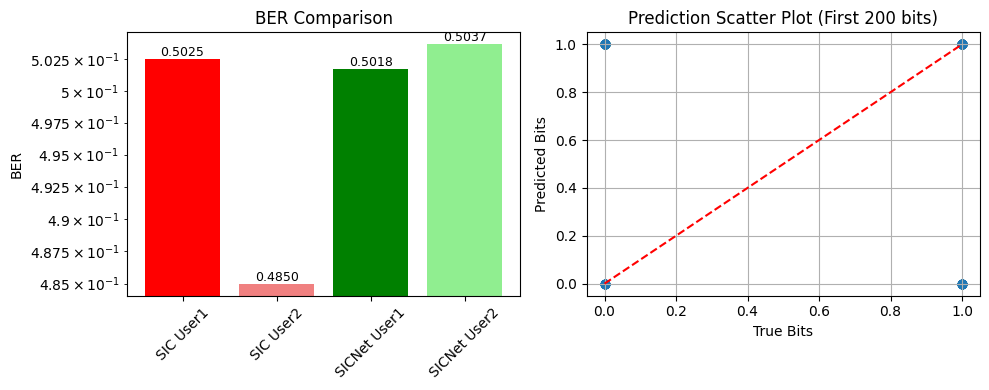

In [11]:
def calculate_ber(true_bits, estimated_bits):
    """Calculate Bit Error Rate"""
    errors = np.sum(true_bits != estimated_bits)
    total = len(true_bits)
    return errors / total

# Generate test data
X_test, y1_test, y2_test = noma.generate_batch(batch_size=200, symbols_per_frame=100)

# Reshape test data
X_test_reshaped = X_test.reshape(-1, 4)
y1_test_flat = y1_test.reshape(-1)
y2_test_flat = y2_test.reshape(-1)

print(f"Test data shapes:")
print(f"X_test_reshaped: {X_test_reshaped.shape}")
print(f"y1_test_flat: {y1_test_flat.shape}")
print(f"y2_test_flat: {y2_test_flat.shape}")

# SICNet predictions
print("\nEvaluating SICNet...")
y1_pred, y2_pred = sicnet.predict(X_test_reshaped, verbose=1)

# Convert probabilities to bits
y1_pred_bits = (y1_pred > 0.5).astype(int).reshape(-1)
y2_pred_bits = (y2_pred > 0.5).astype(int).reshape(-1)

# Make sure lengths match
min_len = min(len(y1_test_flat), len(y1_pred_bits))
y1_test_flat = y1_test_flat[:min_len]
y2_test_flat = y2_test_flat[:min_len]
y1_pred_bits = y1_pred_bits[:min_len]
y2_pred_bits = y2_pred_bits[:min_len]

# Calculate BER for CNN
cnn_ber1 = calculate_ber(y1_test_flat, y1_pred_bits)
cnn_ber2 = calculate_ber(y2_test_flat, y2_pred_bits)

print(f"\n📊 SICNet Results:")
print(f"User 1 BER: {cnn_ber1:.6f}")
print(f"User 2 BER: {cnn_ber2:.6f}")

# For traditional methods, evaluate on a smaller subset
print("\nEvaluating traditional methods (first 10 samples)...")

num_test_symbols = 10
sic_bers1 = []
sic_bers2 = []

for i in range(min(20, X_test.shape[0])):  # Test on 20 frames
    # Extract data for this frame
    received_sample = X_test[i, :num_test_symbols, 0] + 1j * X_test[i, :num_test_symbols, 1]
    h_mag1 = X_test[i, :num_test_symbols, 2]
    h_mag2 = X_test[i, :num_test_symbols, 3]

    # Generate random channel phases (simplified)
    h_complex = np.array([
        h_mag1 * np.exp(1j * np.random.randn(num_test_symbols)),
        h_mag2 * np.exp(1j * np.random.randn(num_test_symbols))
    ])

    # Apply SIC demapper
    sic_bits1, sic_bits2 = TraditionalDemappers.sic_demapper(
        received_sample, h_complex, np.sqrt(0.8), np.sqrt(0.2), noma.constellation
    )

    # Get true bits for this frame
    true_bits1 = y1_test[i, :num_test_symbols*2]  # 10 symbols * 2 bits
    true_bits2 = y2_test[i, :num_test_symbols*2]

    # Calculate BER
    sic_bers1.append(calculate_ber(true_bits1, sic_bits1[:len(true_bits1)]))
    sic_bers2.append(calculate_ber(true_bits2, sic_bits2[:len(true_bits2)]))

# Average BER for traditional methods
sic_ber1_avg = np.mean(sic_bers1)
sic_ber2_avg = np.mean(sic_bers2)

print("\n📊 Results Comparison:")
print("-" * 50)
print(f"SIC Demapper - User 1 BER: {sic_ber1_avg:.6f}")
print(f"SIC Demapper - User 2 BER: {sic_ber2_avg:.6f}")
print(f"SICNet (CNN) - User 1 BER: {cnn_ber1:.6f}")
print(f"SICNet (CNN) - User 2 BER: {cnn_ber2:.6f}")
print(f"\nImprovement User 1: {(1 - cnn_ber1/sic_ber1_avg)*100:.2f}%")
print(f"Improvement User 2: {(1 - cnn_ber2/sic_ber2_avg)*100:.2f}%")

# Visualize results
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
methods = ['SIC User1', 'SIC User2', 'SICNet User1', 'SICNet User2']
bers = [sic_ber1_avg, sic_ber2_avg, cnn_ber1, cnn_ber2]
colors = ['red', 'lightcoral', 'green', 'lightgreen']
bars = plt.bar(methods, bers, color=colors)
plt.ylabel('BER')
plt.title('BER Comparison')
plt.yscale('log')
plt.xticks(rotation=45)
for bar, val in zip(bars, bers):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.subplot(1, 2, 2)
plt.scatter(y1_test_flat[:200], y1_pred_bits[:200], alpha=0.5)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('True Bits')
plt.ylabel('Predicted Bits')
plt.title('Prediction Scatter Plot (First 200 bits)')
plt.grid(True)

plt.tight_layout()
plt.show()